# BNCI2014_009 P300 Dataset Audit

Stage 1 audit for the approved BNCI2014_009 benchmark plan. This notebook checks MOABB metadata and a small subject-1 epoch load before any modeling code is introduced.

In [1]:
from __future__ import annotations

from collections import Counter
from datetime import UTC, datetime
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from moabb.datasets import BNCI2014_009
from moabb.paradigms import P300

REPO_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
ARTIFACT_PATH = REPO_ROOT / "artifacts/experiments/bnci2014_009/stage1_dataset_audit.json"
ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)

DATASET_CACHE_CANDIDATES = (
    Path.home() / "mne_data" / "MNE-bnci-data" / "database" / "data-sets" / "009-2014",
    Path.home() / "mne_data" / "MNE-bnci-data" / "database" / "data-sets" / "009-2014" / "A01T.mat",
)

## Static MOABB Metadata

In [2]:
dataset = BNCI2014_009()
paradigm = P300()
metadata = dataset.METADATA

static_summary = {
    "dataset_class": type(dataset).__name__,
    "dataset_code": dataset.code,
    "paradigm": dataset.paradigm,
    "subjects": [int(subject) for subject in dataset.subject_list],
    "n_subjects": len(dataset.subject_list),
    "event_id": dict(dataset.event_id),
    "interval_seconds": list(dataset.interval),
    "moabb_p300_events": list(paradigm.events),
    "moabb_p300_filters_hz": [list(pair) for pair in paradigm.filters],
    "sampling_rate_hz": float(metadata.acquisition.sampling_rate),
    "n_channels": int(metadata.acquisition.n_channels),
    "channel_types": dict(metadata.acquisition.channel_types),
    "sensors": list(metadata.acquisition.sensors),
    "reference": metadata.acquisition.reference,
    "hardware_filters": metadata.acquisition.filters,
    "line_freq_hz": float(metadata.acquisition.line_freq),
    "experiment_events_ratio": dict(metadata.experiment.events),
    "class_labels": list(metadata.experiment.class_labels),
    "trial_duration_seconds": float(metadata.experiment.trial_duration),
    "stimulus_presentation": dict(metadata.experiment.stimulus_presentation),
}
static_summary

{'dataset_class': 'BNCI2014_009',
 'dataset_code': 'BNCI2014-009',
 'paradigm': 'p300',
 'subjects': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'n_subjects': 10,
 'event_id': {'Target': 2, 'NonTarget': 1},
 'interval_seconds': [0, 0.8],
 'moabb_p300_events': ['Target', 'NonTarget'],
 'moabb_p300_filters_hz': [[1, 24]],
 'sampling_rate_hz': 256.0,
 'n_channels': 16,
 'channel_types': {'eeg': 16},
 'sensors': ['Fz',
  'Cz',
  'Pz',
  'Oz',
  'P3',
  'P4',
  'PO7',
  'PO8',
  'F3',
  'F4',
  'FCz',
  'C3',
  'C4',
  'CP3',
  'CPz',
  'CP4'],
 'reference': 'linked earlobes',
 'hardware_filters': 'bandpass 0.1-20 Hz',
 'line_freq_hz': 50.0,
 'experiment_events_ratio': {'target': 1, 'non_target': 5},
 'class_labels': ['target', 'non_target'],
 'trial_duration_seconds': 16.0,
 'stimulus_presentation': {'stimulus_duration_ms': '125',
  'isi_ms': '125',
  'soa_ms': '250',
  'n_sequences': '8',
  'n_intensifications_per_target': '16',
  'pre_trial_interval_s': '2.0',
  'tti_min_ms': '500'}}

## Subject 1 Epoch Load

In [3]:
def count_existing_cache_entries() -> int:
    total = 0
    for candidate in DATASET_CACHE_CANDIDATES:
        if candidate.is_file():
            total += 1
        elif candidate.is_dir():
            total += sum(1 for path in candidate.rglob("*") if path.is_file())
    return total


cache_files_before = count_existing_cache_entries()
X, labels, epochs_metadata = paradigm.get_data(dataset=dataset, subjects=[1])
cache_files_after = count_existing_cache_entries()

labels = np.asarray(labels)
label_counts = {str(label): int(count) for label, count in Counter(labels.tolist()).items()}
metadata_columns = [str(column) for column in epochs_metadata.columns]
session_counts = (
    {str(key): int(value) for key, value in epochs_metadata["session"].value_counts().sort_index().items()}
    if "session" in epochs_metadata.columns
    else {}
)
run_counts = (
    {str(key): int(value) for key, value in epochs_metadata["run"].value_counts().sort_index().items()}
    if "run" in epochs_metadata.columns
    else {}
)

epoch_summary = {
    "loaded_subjects": [1],
    "X_shape": [int(value) for value in X.shape],
    "X_dtype": str(X.dtype),
    "X_all_finite": bool(np.isfinite(X).all()),
    "label_counts": label_counts,
    "target_fraction": float(label_counts.get("Target", 0) / labels.size),
    "metadata_columns": metadata_columns,
    "session_counts": session_counts,
    "run_counts": run_counts,
    "n_epochs": int(X.shape[0]),
    "n_channels": int(X.shape[1]),
    "n_times": int(X.shape[2]),
    "cache_files_before": int(cache_files_before),
    "cache_files_after": int(cache_files_after),
    "download_observed_in_stage1": bool(cache_files_after > cache_files_before),
}
epoch_summary

{'loaded_subjects': [1],
 'X_shape': [1728, 16, 206],
 'X_dtype': 'float64',
 'X_all_finite': True,
 'label_counts': {'NonTarget': 1440, 'Target': 288},
 'target_fraction': 0.16666666666666666,
 'metadata_columns': ['subject', 'session', 'run'],
 'session_counts': {'0': 576, '1': 576, '2': 576},
 'run_counts': {'0': 1728},
 'n_epochs': 1728,
 'n_channels': 16,
 'n_times': 206,
 'cache_files_before': 0,
 'cache_files_after': 0,
 'download_observed_in_stage1': False}

## Label Balance

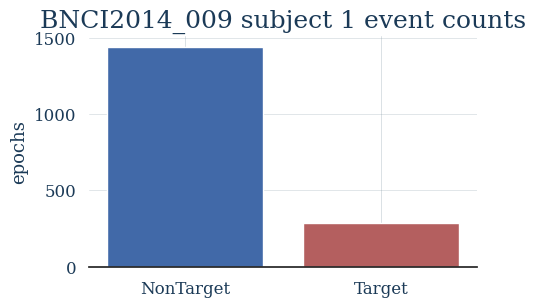

In [4]:
fig, ax = plt.subplots(figsize=(5, 3))
names = list(label_counts)
counts = [label_counts[name] for name in names]
ax.bar(names, counts, color=["#4169a8", "#b45f5f"][: len(names)])
ax.set_title("BNCI2014_009 subject 1 event counts")
ax.set_ylabel("epochs")
ax.grid(axis="y", alpha=0.25)
plt.show()

## Persist Audit JSON

In [5]:
audit_payload = {
    "schema_version": 1,
    "generated_at": datetime.now(UTC).isoformat(),
    "stage": "stage1_dataset_audit",
    "static_summary": static_summary,
    "subject_1_epoch_summary": epoch_summary,
    "stage2_implications": {
        "primary_prediction_unit": "single post-stimulus epoch",
        "primary_labels": ["Target", "NonTarget"],
        "primary_split_group": "subject",
        "primary_metric": "balanced_accuracy",
        "required_secondary_metrics": ["macro_f1", "target_recall", "confusion_matrix", "roc_auc", "pr_auc"],
        "class_imbalance_present": bool(label_counts.get("Target", 0) != label_counts.get("NonTarget", 0)),
        "spectral_models_are_exploratory": True,
    },
}

ARTIFACT_PATH.write_text(json.dumps(audit_payload, indent=2, sort_keys=True) + "\n", encoding="utf-8")
print(f"Wrote {ARTIFACT_PATH}")
print("BNCI2014_009_STAGE1_AUDIT_VERIFIED")

Wrote /home/slauva/Projects/master-thesis-2024-2026/code/artifacts/experiments/bnci2014_009/stage1_dataset_audit.json
BNCI2014_009_STAGE1_AUDIT_VERIFIED
